# BSP6 Final Analysis Notebook

**Physiological Signal Analysis of Distraction-Induced Arousal in Immersive Virtual Reality**

This notebook implements the final analysis used for the BSP6 report. It follows the tutor feedback by:

- using **local pre-round baselines** instead of Condition 1 as baseline;
- removing z-score normalization;
- comparing responses between participants;
- applying objective inclusion criteria for EmotiBit and eye-tracking data;
- reporting eye-tracking validity;
- computing descriptive summaries, Friedman tests, and planned Wilcoxon signed-rank comparisons;
- exporting clean CSV tables and paper-ready figures.

## Expected folder structure

```text
project/
    data/
        P01/
        P02/
        ...
    analysis_outputs/
```

## 1. Imports, paths, and output folders

This section imports the required Python packages and defines the input/output folders.  
The notebook expects participant data to be stored in `data/`, and all generated tables and figures are saved in `analysis_outputs/`.

In [1]:
from pathlib import Path
import os
import re
import csv
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import pyxdf
except ImportError:
    raise ImportError("pyxdf is required. Install it with: pip install pyxdf")

try:
    from scipy.stats import friedmanchisquare, wilcoxon
except ImportError:
    raise ImportError("scipy is required. Install it with: pip install scipy")

warnings.filterwarnings("ignore")

PROJECT_DIR = Path(".")
DATA_DIR = PROJECT_DIR / "data"
OUTPUT_DIR = PROJECT_DIR / "analysis_outputs"
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR = OUTPUT_DIR / "figures"

for d in [OUTPUT_DIR, TABLE_DIR, FIGURE_DIR]:
    d.mkdir(exist_ok=True, parents=True)

print("Project directory:", PROJECT_DIR.resolve())
print("Data directory exists:", DATA_DIR.exists())
print("Data directory:", DATA_DIR.resolve())
print("Output directory:", OUTPUT_DIR.resolve())

if DATA_DIR.exists():
    print("\nContents of data folder:")
    for p in sorted(DATA_DIR.iterdir()):
        print("-", p)
else:
    print("ERROR: data folder not found.")

Project directory: /Users/biancaleoveanu/Desktop/uni semester 6/BSP 6
Data directory exists: True
Data directory: /Users/biancaleoveanu/Desktop/uni semester 6/BSP 6/data
Output directory: /Users/biancaleoveanu/Desktop/uni semester 6/BSP 6/analysis_outputs

Contents of data folder:
- data/.DS_Store
- data/01
- data/02
- data/03
- data/04
- data/05
- data/06
- data/07
- data/08


## 2. Experimental condition metadata

This section defines the nine experimental conditions used in the study.  
The experiment follows a 3 × 3 design combining visual distraction levels with auditory distraction levels.  
The condition labels defined here are reused consistently in all exported tables and figures.

In [2]:
CONDITION_MAP = {
    1: "C1_No_Distraction",
    2: "C2_Visual_Predictable",
    3: "C3_Visual_Unpredictable",
    4: "C4_Audio_Predictable",
    5: "C5_VisualPredictable_AudioPredictable",
    6: "C6_VisualUnpredictable_AudioPredictable",
    7: "C7_Audio_Unpredictable",
    8: "C8_VisualPredictable_AudioUnpredictable",
    9: "C9_VisualUnpredictable_AudioUnpredictable",
}

CONDITION_LABELS = {
    "C1_No_Distraction": "C1\nNo",
    "C2_Visual_Predictable": "C2\nVis-P",
    "C3_Visual_Unpredictable": "C3\nVis-U",
    "C4_Audio_Predictable": "C4\nAud-P",
    "C5_VisualPredictable_AudioPredictable": "C5\nVisP+AudP",
    "C6_VisualUnpredictable_AudioPredictable": "C6\nVisU+AudP",
    "C7_Audio_Unpredictable": "C7\nAud-U",
    "C8_VisualPredictable_AudioUnpredictable": "C8\nVisP+AudU",
    "C9_VisualUnpredictable_AudioUnpredictable": "C9\nVisU+AudU",
}

CONDITION_GROUP_MAP = {
    1: "No distraction",
    2: "Visual only",
    3: "Visual only",
    4: "Audio only",
    5: "Combined visual + audio",
    6: "Combined visual + audio",
    7: "Audio only",
    8: "Combined visual + audio",
    9: "Combined visual + audio",
}

PREDICTABILITY_MAP = {
    1: "None",
    2: "Predictable",
    3: "Unpredictable",
    4: "Predictable",
    5: "Predictable",
    6: "Mixed",
    7: "Unpredictable",
    8: "Mixed",
    9: "Unpredictable",
}

CONDITION_ORDER = list(CONDITION_MAP.values())
GROUP_ORDER = [
    "No distraction",
    "Visual only",
    "Audio only",
    "Combined visual + audio"
]

EXPECTED_ROUNDS = 9
EXPECTED_QUESTIONNAIRE_ANSWERS = 54

condition_metadata = pd.DataFrame([
    {
        "round_index": i,
        "condition": CONDITION_MAP[i],
        "condition_group": CONDITION_GROUP_MAP[i],
        "predictability": PREDICTABILITY_MAP[i],
        "label": CONDITION_LABELS[CONDITION_MAP[i]],
    }
    for i in range(1, 10)
])

condition_metadata.to_csv(TABLE_DIR / "condition_metadata.csv", index=False)
condition_metadata

,round_index,condition,condition_group,predictability,label
0,1,C1_No_Distraction,No distraction,None,C1\nNo
1,2,C2_Visual_Predictable,Visual only,Predictable,C2\nVis-P
2,3,C3_Visual_Unpredictable,Visual only,Unpredictable,C3\nVis-U
3,4,C4_Audio_Predictable,Audio only,Predictable,C4\nAud-P
4,5,C5_VisualPredictable_AudioPredictable,Combined visual + audio,Predictable,C5\nVisP+AudP
5,6,C6_VisualUnpredictable_AudioPredictable,Combined visual + audio,Mixed,C6\nVisU+AudP
6,7,C7_Audio_Unpredictable,Audio only,Unpredictable,C7\nAud-U
7,8,C8_VisualPredictable_AudioUnpredictable,Combined visual + audio,Mixed,C8\nVisP+AudU
8,9,C9_VisualUnpredictable_AudioUnpredictable,Combined visual + audio,Unpredictable,C9\nVisU+AudU


## 3. Locate participant files

This section scans the `data/` directory and identifies the files available for each participant: event logs, eye-tracking files, and XDF recordings.  
The resulting availability table is exported to document which data sources were available before analysis.

In [3]:
def normalize_pid(folder_name):
    name = str(folder_name).strip()

    if name.upper().startswith("P"):
        num = re.findall(r"\d+", name)
        if num:
            return f"P{int(num[0]):02d}"

    if name.isdigit():
        return f"P{int(name):02d}"

    return name


def find_participant_files(data_dir):
    participants = {}

    for folder in sorted(data_dir.iterdir()):
        if not folder.is_dir():
            continue

        pid = normalize_pid(folder.name)

        participants[pid] = {
            "folder": folder,
            "event_log": None,
            "eye_tracking": None,
            "xdf_files": [],
        }

        for f in folder.glob("*"):
            name = f.name.lower()

            if f.suffix.lower() in [".csv", ".xlsx"] and "event_log" in name:
                if participants[pid]["event_log"] is None or f.suffix.lower() == ".csv":
                    participants[pid]["event_log"] = f

            elif f.suffix.lower() == ".csv" and "eyetracking" in name:
                participants[pid]["eye_tracking"] = f

            elif f.suffix.lower() == ".xdf":
                participants[pid]["xdf_files"].append(f)

    return participants


participants = find_participant_files(DATA_DIR)

availability_rows = []
for pid, info in participants.items():
    row = {
        "participant": pid,
        "folder": str(info["folder"]),
        "has_event_log": info["event_log"] is not None,
        "event_log": str(info["event_log"]) if info["event_log"] else None,
        "has_eye_tracking": info["eye_tracking"] is not None,
        "eye_tracking": str(info["eye_tracking"]) if info["eye_tracking"] else None,
        "n_xdf_files": len(info["xdf_files"]),
        "xdf_files": "; ".join([str(x) for x in info["xdf_files"]]),
    }
    availability_rows.append(row)

data_availability = pd.DataFrame(availability_rows).sort_values("participant")
data_availability.to_csv(TABLE_DIR / "data_availability_table.csv", index=False)
data_availability

,participant,folder,has_event_log,event_log,has_eye_tracking,eye_tracking,n_xdf_files,xdf_files
0,P01,data/01,True,data/01/event_log_P01.csv,True,data/01/eyetracking-raw_P01.csv,1,data/01/lab_recorder_P01.xdf
1,P02,data/02,True,data/02/event_log_P02.csv,True,data/02/eyetracking-raw_P02.csv,2,data/02/lab_recorder_run2_P02.xdf; data/02/lab...
2,P03,data/03,True,data/03/event_log_P03.csv,True,data/03/eyetracking-raw_P03.csv,1,data/03/labrecorder_P03.xdf
3,P04,data/04,True,data/04/event_log_P04.csv,True,data/04/eyetracking-raw_P04.csv,1,data/04/labrecorder_P04.xdf
4,P05,data/05,True,data/05/event_log_P05.csv,True,data/05/eyetracking-raw_P05.csv,1,data/05/labrecorder_P05.xdf
5,P06,data/06,True,data/06/event_log_P06.csv,True,data/06/eyetracking-raw_P06.csv,1,data/06/labrecorder_P06.xdf
6,P07,data/07,True,data/07/event_log_P07.csv,True,data/07/eyetracking-raw_P07.csv,1,data/07/labrecorder_P07.xdf
7,P08,data/08,True,data/08/event_log_P08.csv,True,data/08/eyetracking-raw_P08.csv,1,data/08/labrecorder_P08.xdf


## 4. Load and clean event logs

Event logs contain Unity markers such as experiment starts, round starts, round ends, card flips, matches, and questionnaire answers.  
Some CSV rows contain commas inside text fields, so this section repairs malformed rows before analysis.  
For P01, multiple session attempts were present, so the most complete final session is selected automatically.

In [4]:
EVENT_COLS = [
    "timestamp",
    "event_type",
    "round_index",
    "condition_id",
    "object_id",
    "extra_1",
    "extra_2",
]


def load_event_log(path):
    path = Path(path)

    if path.suffix.lower() == ".xlsx":
        df = pd.read_excel(path)
        df.columns = [str(c).strip() for c in df.columns]

    else:
        rows = []
        with open(path, "r", encoding="utf-8", errors="replace") as f:
            reader = csv.reader(f)
            header = next(reader, None)

            for row in reader:
                if len(row) == 7:
                    rows.append(row)
                elif len(row) > 7:
                    # Some text fields may contain commas.
                    fixed_row = row[:6] + [",".join(row[6:])]
                    rows.append(fixed_row)
                elif len(row) < 7:
                    fixed_row = row + [""] * (7 - len(row))
                    rows.append(fixed_row)

        df = pd.DataFrame(rows, columns=EVENT_COLS)

    for col in EVENT_COLS:
        if col not in df.columns:
            df[col] = np.nan

    df = df[EVENT_COLS].copy()

    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
    df = df.dropna(subset=["timestamp"]).copy()

    df["event_type"] = df["event_type"].astype(str).str.strip()
    df["round_index"] = pd.to_numeric(df["round_index"], errors="coerce")
    df["condition_id"] = df["condition_id"].astype(str)
    df["object_id"] = df["object_id"].astype(str)
    df["extra_1"] = df["extra_1"].astype(str)
    df["extra_2"] = df["extra_2"].astype(str).str.replace(";", "", regex=False)

    df = df.sort_values("timestamp").reset_index(drop=True)

    return df


def split_sessions_by_experiment_start(df):
    df = df.sort_values("timestamp").reset_index(drop=True)
    start_idxs = df.index[df["event_type"] == "EXPERIMENT_START"].tolist()

    if not start_idxs:
        return [df.copy()]

    sessions = []

    for i, start_idx in enumerate(start_idxs):
        end_idx = start_idxs[i + 1] if i + 1 < len(start_idxs) else len(df)
        session = df.iloc[start_idx:end_idx].copy().reset_index(drop=True)
        if len(session) > 0:
            sessions.append(session)

    return sessions


def score_session(session):
    counts = session["event_type"].value_counts()

    round_starts = int(counts.get("ROUND_START", 0))
    round_ends = int(counts.get("ROUND_END", 0))
    questionnaire_answers = int(counts.get("QUESTIONNAIRE_ANSWER", 0))
    experiment_ends = int(counts.get("EXPERIMENT_END", 0))

    has_expected_rounds = round_starts >= EXPECTED_ROUNDS and round_ends >= EXPECTED_ROUNDS
    has_expected_questionnaire = questionnaire_answers >= EXPECTED_QUESTIONNAIRE_ANSWERS
    has_experiment_end = experiment_ends >= 1

    score = 0
    score += min(round_starts, EXPECTED_ROUNDS) * 10
    score += min(round_ends, EXPECTED_ROUNDS) * 10
    score += min(questionnaire_answers, EXPECTED_QUESTIONNAIRE_ANSWERS)
    score += has_experiment_end * 20
    score += has_expected_rounds * 50
    score += has_expected_questionnaire * 50

    return {
        "n_rows": len(session),
        "experiment_start": int(counts.get("EXPERIMENT_START", 0)),
        "experiment_end": experiment_ends,
        "round_start": round_starts,
        "round_end": round_ends,
        "questionnaire_answer": questionnaire_answers,
        "has_expected_rounds": has_expected_rounds,
        "has_expected_questionnaire": has_expected_questionnaire,
        "has_experiment_end": has_experiment_end,
        "score": score,
        "first_time": session["timestamp"].min(),
        "last_time": session["timestamp"].max(),
    }


def trim_to_expected_final_session(session):
    session = session.sort_values("timestamp").reset_index(drop=True)

    start_idxs = session.index[session["event_type"] == "EXPERIMENT_START"].tolist()
    if start_idxs:
        session = session.iloc[start_idxs[0]:].copy().reset_index(drop=True)

    end_idxs = session.index[session["event_type"] == "EXPERIMENT_END"].tolist()
    if end_idxs:
        session = session.iloc[:end_idxs[0] + 1].copy().reset_index(drop=True)

    round_start_idxs = session.index[session["event_type"] == "ROUND_START"].tolist()

    if len(round_start_idxs) > EXPECTED_ROUNDS:
        selected_round_start = round_start_idxs[-EXPECTED_ROUNDS]
        session = session.iloc[selected_round_start:].copy().reset_index(drop=True)

        end_idxs = session.index[session["event_type"] == "EXPERIMENT_END"].tolist()
        if end_idxs:
            session = session.iloc[:end_idxs[0] + 1].copy().reset_index(drop=True)

    return session


def clean_p01_event_log(df):
    sessions = split_sessions_by_experiment_start(df)
    scored = []

    for i, s in enumerate(sessions):
        row = score_session(s)
        row["session_candidate"] = i
        scored.append(row)

    candidates = pd.DataFrame(scored)

    complete = candidates[
        (candidates["has_expected_rounds"] == True)
        & (candidates["has_expected_questionnaire"] == True)
    ].copy()

    if len(complete) > 0:
        selected_idx = int(
            complete.sort_values(["first_time", "score"]).iloc[-1]["session_candidate"]
        )
    else:
        selected_idx = int(
            candidates.sort_values(["score", "first_time"]).iloc[-1]["session_candidate"]
        )

    cleaned = sessions[selected_idx].copy()
    cleaned = trim_to_expected_final_session(cleaned).reset_index(drop=True)

    return cleaned, candidates


event_logs = {}

for pid, info in participants.items():
    if info["event_log"] is None:
        continue

    df = load_event_log(info["event_log"])

    if pid == "P01":
        cleaned, p01_candidates = clean_p01_event_log(df)
        event_logs[pid] = cleaned
        p01_candidates.to_csv(TABLE_DIR / "p01_session_candidates.csv", index=False)
        cleaned.to_csv(TABLE_DIR / "event_log_P01_cleaned_final_session.csv", index=False)
    else:
        event_logs[pid] = df

print("Loaded event logs:", list(event_logs.keys()))

Loaded event logs: ['P01', 'P02', 'P03', 'P04', 'P05', 'P06', 'P07', 'P08']


## 5. Behavioral event-log analysis

This section summarizes behavioral information from the event logs, including round duration, number of card flips, matches, mismatches, rechecks, and questionnaire answers.  
These outputs are mainly used for quality control and to document whether each participant completed all rounds.

In [5]:
def build_round_behavior(pid, df):
    rows = []

    df = df.copy()
    df["round_index"] = pd.to_numeric(df["round_index"], errors="coerce")
    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
    df = df.dropna(subset=["timestamp"]).copy()

    for round_idx in range(1, 10):
        rdf = df[df["round_index"] == round_idx].copy()

        if rdf.empty:
            rows.append({
                "participant": pid,
                "round_index": round_idx,
                "condition": CONDITION_MAP.get(round_idx),
                "condition_group": CONDITION_GROUP_MAP.get(round_idx),
                "round_start": pd.NaT,
                "round_end": pd.NaT,
                "duration_sec": np.nan,
                "has_round_start": False,
                "has_round_end": False,
                "round_complete": False,
                "card_flips": 0,
                "matches": 0,
                "mismatches": 0,
                "rechecks": 0,
                "thinking_time_events": 0,
                "questionnaire_answers": 0,
                "mean_thinking_time": np.nan,
            })
            continue

        start_rows = rdf[rdf["event_type"] == "ROUND_START"]
        end_rows = rdf[rdf["event_type"] == "ROUND_END"]

        has_round_start = len(start_rows) > 0
        has_round_end = len(end_rows) > 0

        round_start = start_rows["timestamp"].iloc[0] if has_round_start else rdf["timestamp"].min()
        round_end = end_rows["timestamp"].iloc[-1] if has_round_end else rdf["timestamp"].max()
        duration_sec = (round_end - round_start).total_seconds()

        if duration_sec < 0:
            duration_sec = np.nan

        row = {
            "participant": pid,
            "round_index": round_idx,
            "condition": CONDITION_MAP.get(round_idx),
            "condition_group": CONDITION_GROUP_MAP.get(round_idx),
            "round_start": round_start,
            "round_end": round_end,
            "duration_sec": duration_sec,
            "has_round_start": has_round_start,
            "has_round_end": has_round_end,
            "round_complete": has_round_start and has_round_end,
            "card_flips": int((rdf["event_type"] == "CARD_FLIP").sum()),
            "matches": int((rdf["event_type"] == "MATCH").sum()),
            "mismatches": int((rdf["event_type"] == "MISMATCH").sum()),
            "rechecks": int((rdf["event_type"] == "RECHECK").sum()),
            "thinking_time_events": int((rdf["event_type"] == "THINKING_TIME").sum()),
            "questionnaire_answers": int((rdf["event_type"] == "QUESTIONNAIRE_ANSWER").sum()),
        }

        thinking = rdf[rdf["event_type"] == "THINKING_TIME"].copy()
        vals = []

        for _, tr in thinking.iterrows():
            for col in ["extra_1", "extra_2"]:
                nums = re.findall(r"[-+]?\d*\.\d+|[-+]?\d+", str(tr[col]))
                if nums:
                    vals.append(float(nums[0]))
                    break

        row["mean_thinking_time"] = np.mean(vals) if vals else np.nan

        rows.append(row)

    return pd.DataFrame(rows)


behavior_parts = []

for pid, df in event_logs.items():
    behavior_parts.append(build_round_behavior(pid, df))

behavior_rounds = pd.concat(behavior_parts, ignore_index=True)

behavior_rounds.to_csv(TABLE_DIR / "behavior_round_summary_cleaned.csv", index=False)

behavior_quality = behavior_rounds.groupby("participant").agg(
    n_rounds=("round_index", "count"),
    complete_rounds=("round_complete", "sum"),
    total_questionnaire_answers=("questionnaire_answers", "sum"),
    mean_duration_sec=("duration_sec", "mean"),
    min_duration_sec=("duration_sec", "min"),
    max_duration_sec=("duration_sec", "max"),
).reset_index()

behavior_quality.to_csv(TABLE_DIR / "behavior_quality_summary.csv", index=False)

behavior_condition = (
    behavior_rounds
    .groupby(["condition", "condition_group"], as_index=False)
    .agg(
        mean_duration_sec=("duration_sec", "mean"),
        sd_duration_sec=("duration_sec", "std"),
        mean_card_flips=("card_flips", "mean"),
        sd_card_flips=("card_flips", "std"),
        mean_matches=("matches", "mean"),
        sd_matches=("matches", "std"),
        mean_mismatches=("mismatches", "mean"),
        sd_mismatches=("mismatches", "std"),
        mean_rechecks=("rechecks", "mean"),
        sd_rechecks=("rechecks", "std"),
        mean_thinking_time=("mean_thinking_time", "mean"),
        sd_thinking_time=("mean_thinking_time", "std"),
        n_participants=("participant", "nunique"),
    )
)

behavior_condition["condition"] = pd.Categorical(
    behavior_condition["condition"],
    categories=CONDITION_ORDER,
    ordered=True
)
behavior_condition = behavior_condition.sort_values("condition")
behavior_condition.to_csv(TABLE_DIR / "behavior_condition_summary.csv", index=False)

behavior_quality, behavior_condition

(  participant  n_rounds  complete_rounds  total_questionnaire_answers  \
 0         P01         9                9                           54   
 1         P02         9                9                           54   
 2         P03         9                9                           54   
 3         P04         9                9                           54   
 4         P05         9                9                           54   
 5         P06         9                9                           54   
 6         P07         9                9                           54   
 7         P08         9                9                           54   
 
    mean_duration_sec  min_duration_sec  max_duration_sec  
 0          42.108556            29.033            65.506  
 1          52.237778            38.963            75.678  
 2          39.402222            34.408            53.876  
 3          51.714000            38.377            62.993  
 4          47.090000           

## 6. Questionnaire analysis

This section extracts NASA-TLX questionnaire responses after each round.  
Scores are adjusted so that higher values consistently indicate higher perceived workload.  
The adjusted questionnaire scores are then summarized by participant and by condition.

In [6]:
def extract_questionnaire(pid, df):
    qdf = df[df["event_type"] == "QUESTIONNAIRE_ANSWER"].copy()
    rows = []

    for _, r in qdf.iterrows():
        round_idx = int(r["round_index"]) if not pd.isna(r["round_index"]) else np.nan
        text = f"{r['object_id']} {r['extra_1']} {r['extra_2']}"
        nums = re.findall(r"[-+]?\d*\.\d+|[-+]?\d+", text)
        score = float(nums[-1]) if nums else np.nan

        rows.append({
            "participant": pid,
            "round_index": round_idx,
            "condition": CONDITION_MAP.get(round_idx),
            "condition_group": CONDITION_GROUP_MAP.get(round_idx),
            "question_raw": str(r["object_id"]).strip(),
            "extra_1": str(r["extra_1"]),
            "extra_2": str(r["extra_2"]),
            "score": score,
        })

    return pd.DataFrame(rows)


def adjust_questionnaire_score(row):
    score = row["score"]

    if pd.isna(score):
        return np.nan

    question = str(row["question_raw"]).strip().upper()

    # Q4 is assumed to reflect perceived success/performance.
    # Higher success means lower workload, so we reverse it.
    if question == "Q4":
        return 100 - score

    return score


questionnaire_parts = []

for pid, df in event_logs.items():
    questionnaire_parts.append(extract_questionnaire(pid, df))

questionnaire = pd.concat(questionnaire_parts, ignore_index=True)
questionnaire["adjusted_score"] = questionnaire.apply(adjust_questionnaire_score, axis=1)

questionnaire.to_csv(TABLE_DIR / "questionnaire_scores_cleaned_adjusted.csv", index=False)

questionnaire_quality = questionnaire.groupby("participant").agg(
    n_answers=("score", "count"),
    n_rounds=("round_index", "nunique"),
    mean_score=("score", "mean"),
    mean_adjusted_score=("adjusted_score", "mean"),
    min_score=("score", "min"),
    max_score=("score", "max"),
).reset_index()

questionnaire_quality.to_csv(TABLE_DIR / "questionnaire_quality_summary.csv", index=False)

questionnaire_condition = (
    questionnaire
    .dropna(subset=["adjusted_score"])
    .groupby(["condition", "condition_group"], as_index=False)
    .agg(
        mean_adjusted_score=("adjusted_score", "mean"),
        sd_adjusted_score=("adjusted_score", "std"),
        n_answers=("adjusted_score", "count"),
        n_participants=("participant", "nunique"),
    )
)

questionnaire_condition["condition"] = pd.Categorical(
    questionnaire_condition["condition"],
    categories=CONDITION_ORDER,
    ordered=True
)

questionnaire_condition = questionnaire_condition.sort_values("condition")
questionnaire_condition.to_csv(TABLE_DIR / "questionnaire_condition_summary_adjusted.csv", index=False)

questionnaire_quality, questionnaire_condition

(  participant  n_answers  n_rounds  mean_score  mean_adjusted_score  \
 0         P01         54         9   33.537037            34.129630   
 1         P02         54         9   53.888889            58.592593   
 2         P03         54         9   46.870370            42.796296   
 3         P04         54         9   50.092593            46.722222   
 4         P05         54         9   53.333333            47.555556   
 5         P06         54         9   45.944444            37.870370   
 6         P07         54         9   35.851852            20.740741   
 7         P08         54         9   51.018519            46.981481   
 
    min_score  max_score  
 0        0.0       80.0  
 1       19.0       84.0  
 2       13.0       86.0  
 3        5.0      100.0  
 4        0.0       98.0  
 5       10.0       94.0  
 6        0.0       97.0  
 7       17.0       77.0  ,
                                    condition          condition_group  \
 0                          C1_N

## 7. XDF stream inspection

This section inspects the streams stored in each XDF recording.  
It identifies useful streams such as EDA, heart rate, and Unity/LSL event markers before signal processing begins.

In [7]:
def load_xdf_streams(xdf_path):
    streams, header = pyxdf.load_xdf(str(xdf_path))
    return streams


def stream_name(stream):
    return stream["info"]["name"][0]


def stream_type(stream):
    return stream["info"]["type"][0] if "type" in stream["info"] else ""


def summarize_xdf_streams(pid, xdf_path):
    streams = load_xdf_streams(xdf_path)
    rows = []

    for s in streams:
        ts = np.asarray(s.get("time_stamps", []))
        rows.append({
            "participant": pid,
            "xdf_file": Path(xdf_path).name,
            "stream_name": stream_name(s),
            "stream_type": stream_type(s),
            "n_samples": len(ts),
            "duration_sec": float(ts[-1] - ts[0]) if len(ts) > 1 else np.nan,
        })

    return pd.DataFrame(rows)


xdf_summaries = []

for pid, info in participants.items():
    for xdf in info["xdf_files"]:
        try:
            xdf_summaries.append(summarize_xdf_streams(pid, xdf))
        except Exception as e:
            print("XDF error:", pid, xdf, e)

xdf_stream_summary = pd.concat(xdf_summaries, ignore_index=True) if xdf_summaries else pd.DataFrame()
xdf_stream_summary.to_csv(TABLE_DIR / "xdf_stream_summary_updated.csv", index=False)

useful_xdf_streams = xdf_stream_summary[
    xdf_stream_summary["stream_name"].str.contains(
        "EDA|HR|Trigger|Marker|Unity|DataSync|BSP6",
        case=False,
        na=False
    )
    | xdf_stream_summary["stream_type"].str.contains(
        "EDA|HR|Marker|Trigger",
        case=False,
        na=False
    )
].copy()

useful_xdf_streams = useful_xdf_streams.sort_values(
    ["participant", "xdf_file", "stream_name"]
)
useful_xdf_streams.to_csv(TABLE_DIR / "xdf_useful_streams_summary.csv", index=False)

useful_xdf_streams

Stream 18: Calculated effective sampling rate 5.3270 Hz is different from specified rate 7.5000 Hz.
Stream 14: Calculated effective sampling rate 5.2893 Hz is different from specified rate 7.5000 Hz.
Stream 1: Segments and clock-segments differ
Stream 3: Segments and clock-segments differ
Stream 8: Segments and clock-segments differ
Stream 4: Segments and clock-segments differ
Stream 17: Segments and clock-segments differ
Stream 13: Segments and clock-segments differ
Stream 12: Segments and clock-segments differ
Stream 19: Segments and clock-segments differ
Stream 15: Segments and clock-segments differ
Stream 18: Segments and clock-segments differ
Stream 16: Segments and clock-segments differ
Stream 2: Segments and clock-segments differ
Stream 11: Segments and clock-segments differ
Stream 14: Segments and clock-segments differ
Stream 20: Segments and clock-segments differ


,participant,xdf_file,stream_name,stream_type,n_samples,duration_sec
15,P01,lab_recorder_P01.xdf,DataSyncMarker,Markers,1018,977.502630
9,P01,lab_recorder_P01.xdf,EDA,EDA,432,273.910281
13,P01,lab_recorder_P01.xdf,HR,HeartRate,37,273.867014
56,P02,lab_recorder_run1_P02.xdf,DataSyncMarker,Markers,0,NaN
55,P02,lab_recorder_run1_P02.xdf,EDA,EDA,264,17.495664
58,P02,lab_recorder_run1_P02.xdf,HR,HeartRate,22,17.335891
39,P02,lab_recorder_run2_P02.xdf,DataSyncMarker,Markers,1235,839.540468
29,P02,lab_recorder_run2_P02.xdf,EDA,EDA,786,52.286864
32,P02,lab_recorder_run2_P02.xdf,HR,HeartRate,69,51.719546
79,P03,labrecorder_P03.xdf,DataSyncMarker,Markers,966,764.149682


## 8. Marker and stream utilities

This section defines helper functions for extracting marker streams, finding physiological streams, parsing marker values, and converting XDF streams into numeric data frames.  
These functions are reused during EmotiBit processing.

In [8]:
def find_marker_stream(streams):
    candidates = []

    for s in streams:
        name = stream_name(s).lower()
        stype = stream_type(s).lower()
        n = len(s.get("time_stamps", []))

        if n == 0:
            continue

        if (
            "trigger" in name
            or "marker" in name
            or "unity" in name
            or "datasync" in name
            or "bsp6" in name
            or "marker" in stype
            or "trigger" in stype
        ):
            candidates.append(s)

    if not candidates:
        return None

    return max(candidates, key=lambda s: len(s.get("time_stamps", [])))


def find_signal_stream(streams, keyword):
    keyword = keyword.lower()
    candidates = []

    for s in streams:
        name = stream_name(s).lower()
        stype = stream_type(s).lower()
        n = len(s.get("time_stamps", []))

        if n == 0:
            continue

        if keyword in name or keyword in stype:
            candidates.append(s)

    if not candidates:
        return None

    return max(candidates, key=lambda s: len(s.get("time_stamps", [])))


def parse_marker_value(value):
    if isinstance(value, (list, np.ndarray)):
        if len(value) > 0:
            value = value[0]

    value = str(value).strip()
    value = value.strip("[]").strip("'").strip('"')

    if "|" in value:
        parts = value.split("|")

        event = parts[1] if len(parts) > 1 else ""
        round_idx = pd.to_numeric(parts[2], errors="coerce") if len(parts) > 2 else np.nan
        condition = parts[3] if len(parts) > 3 else ""
        object_id = parts[4] if len(parts) > 4 else ""
        extra_1 = parts[5] if len(parts) > 5 else ""
        extra_2 = parts[6] if len(parts) > 6 else ""

        return event, round_idx, condition, object_id, extra_1, extra_2, value

    parts = {}

    for chunk in value.split(";"):
        if "=" in chunk:
            k, v = chunk.split("=", 1)
            parts[k.strip()] = v.strip()

    event = parts.get("event", value)
    round_idx = pd.to_numeric(parts.get("round", np.nan), errors="coerce")
    condition = parts.get("condition", "")
    object_id = parts.get("object", "")
    extra_1 = parts.get("extra1", "")
    extra_2 = parts.get("extra2", "")

    return event, round_idx, condition, object_id, extra_1, extra_2, value


def extract_markers(marker_stream):
    ts = np.asarray(marker_stream["time_stamps"], dtype=float)
    series = marker_stream["time_series"]

    rows = []

    for t, v in zip(ts, series):
        event, round_idx, condition, object_id, extra_1, extra_2, raw = parse_marker_value(v)
        rows.append({
            "xdf_time": float(t),
            "event_type": event,
            "round_index": round_idx,
            "condition_raw": condition,
            "object_id": object_id,
            "extra_1": extra_1,
            "extra_2": extra_2,
            "raw_marker": raw,
        })

    markers = pd.DataFrame(rows)
    markers["round_index"] = pd.to_numeric(markers["round_index"], errors="coerce")

    return markers


def numeric_stream_df(stream, value_name):
    ts = np.asarray(stream["time_stamps"], dtype=float)
    data = np.asarray(stream["time_series"], dtype=float)

    if data.ndim == 2:
        values = data[:, 0]
    else:
        values = data

    df = pd.DataFrame({
        "xdf_time": ts,
        value_name: values
    })

    df[value_name] = pd.to_numeric(df[value_name], errors="coerce")
    df = df.dropna(subset=[value_name]).copy()

    return df

## 9. EmotiBit EDA/HR analysis with local baseline

This section extracts EDA and heart-rate features from the XDF recordings.  
For each participant and round, signals are segmented using synchronized LSL event markers.  
A local baseline is computed from the 15 seconds immediately before each round, and each response is expressed as a difference from that local baseline.

In [9]:
LOCAL_BASELINE_SEC = 15

def signal_features_in_window(signal_df, value_col, start, end):
    w = signal_df[
        (signal_df["xdf_time"] >= start)
        & (signal_df["xdf_time"] <= end)
    ].copy()

    if len(w) < 5:
        return None

    x = w["xdf_time"].values.astype(float)
    y = w[value_col].values.astype(float)

    mask = np.isfinite(y)
    x = x[mask]
    y = y[mask]

    if len(y) < 5:
        return None

    if len(y) >= 2:
        slope = np.polyfit(x - x[0], y, 1)[0]
    else:
        slope = np.nan

    return {
        f"{value_col}_n_samples": len(y),
        f"{value_col}_mean": np.mean(y),
        f"{value_col}_median": np.median(y),
        f"{value_col}_sd": np.std(y, ddof=1) if len(y) > 1 else np.nan,
        f"{value_col}_min": np.min(y),
        f"{value_col}_max": np.max(y),
        f"{value_col}_range": np.max(y) - np.min(y),
        f"{value_col}_start": y[0],
        f"{value_col}_end": y[-1],
        f"{value_col}_change": y[-1] - y[0],
        f"{value_col}_slope": slope,
    }


def local_baseline_features(signal_df, value_col, start, baseline_sec=LOCAL_BASELINE_SEC):
    w = signal_df[
        (signal_df["xdf_time"] >= start - baseline_sec)
        & (signal_df["xdf_time"] < start)
    ].copy()

    if len(w) < 5:
        return {
            f"{value_col}_baseline_n_samples": len(w),
            f"{value_col}_local_baseline": np.nan,
        }

    y = pd.to_numeric(w[value_col], errors="coerce")
    y = y[np.isfinite(y)]

    if len(y) < 5:
        return {
            f"{value_col}_baseline_n_samples": len(y),
            f"{value_col}_local_baseline": np.nan,
        }

    return {
        f"{value_col}_baseline_n_samples": len(y),
        f"{value_col}_local_baseline": y.mean(),
    }


def emotibit_round_analysis(pid, xdf_path):
    streams = load_xdf_streams(xdf_path)

    marker_stream = find_marker_stream(streams)
    eda_stream = find_signal_stream(streams, "eda")
    hr_stream = find_signal_stream(streams, "hr")

    if marker_stream is None:
        print(pid, Path(xdf_path).name, "no marker stream")
        return pd.DataFrame()

    markers = extract_markers(marker_stream)

    eda_df = numeric_stream_df(eda_stream, "eda") if eda_stream is not None else None
    hr_df = numeric_stream_df(hr_stream, "hr") if hr_stream is not None else None

    rows = []

    for round_idx in range(1, 10):
        mround = markers[markers["round_index"] == round_idx].copy()

        start_rows = mround[mround["event_type"] == "ROUND_START"]
        end_rows = mround[mround["event_type"] == "ROUND_END"]

        if len(start_rows) == 0 or len(end_rows) == 0:
            continue

        start = start_rows["xdf_time"].iloc[0]
        end = end_rows["xdf_time"].iloc[-1]

        if end <= start:
            continue

        row = {
            "participant": pid,
            "xdf_file": Path(xdf_path).name,
            "round_index": round_idx,
            "condition": CONDITION_MAP.get(round_idx),
            "condition_group": CONDITION_GROUP_MAP.get(round_idx),
            "predictability": PREDICTABILITY_MAP.get(round_idx),
            "start_xdf_time": start,
            "end_xdf_time": end,
            "duration_sec": end - start,
            "marker_stream": stream_name(marker_stream),
            "eda_stream": stream_name(eda_stream) if eda_stream is not None else None,
            "hr_stream": stream_name(hr_stream) if hr_stream is not None else None,
        }

        if eda_df is not None:
            eda_feats = signal_features_in_window(eda_df, "eda", start, end)
            eda_base = local_baseline_features(eda_df, "eda", start)

            if eda_feats is not None:
                row.update(eda_feats)
                row.update(eda_base)
                row["delta_eda_local"] = row["eda_mean"] - row["eda_local_baseline"]

        if hr_df is not None:
            hr_feats = signal_features_in_window(hr_df, "hr", start, end)
            hr_base = local_baseline_features(hr_df, "hr", start)

            if hr_feats is not None:
                row.update(hr_feats)
                row.update(hr_base)
                row["delta_hr_local"] = row["hr_mean"] - row["hr_local_baseline"]

        rows.append(row)

    return pd.DataFrame(rows)


emotibit_parts = []

for pid, info in participants.items():
    for xdf in info["xdf_files"]:
        try:
            tmp = emotibit_round_analysis(pid, xdf)
            if len(tmp) > 0:
                emotibit_parts.append(tmp)
        except Exception as e:
            print("EmotiBit analysis error:", pid, xdf, e)

emotibit_rounds = pd.concat(emotibit_parts, ignore_index=True) if emotibit_parts else pd.DataFrame()
emotibit_rounds.to_csv(TABLE_DIR / "emotibit_round_features_local_baseline.csv", index=False)

emotibit_rounds.head()

Stream 18: Calculated effective sampling rate 5.3270 Hz is different from specified rate 7.5000 Hz.
Stream 14: Calculated effective sampling rate 5.2893 Hz is different from specified rate 7.5000 Hz.
Stream 1: Segments and clock-segments differ
Stream 3: Segments and clock-segments differ
Stream 8: Segments and clock-segments differ
Stream 4: Segments and clock-segments differ
Stream 17: Segments and clock-segments differ
Stream 13: Segments and clock-segments differ
Stream 12: Segments and clock-segments differ
Stream 19: Segments and clock-segments differ
Stream 15: Segments and clock-segments differ
Stream 18: Segments and clock-segments differ
Stream 16: Segments and clock-segments differ
Stream 2: Segments and clock-segments differ
Stream 11: Segments and clock-segments differ
Stream 14: Segments and clock-segments differ
Stream 20: Segments and clock-segments differ


P02 lab_recorder_run1_P02.xdf no marker stream


,participant,xdf_file,round_index,condition,condition_group,predictability,start_xdf_time,end_xdf_time,duration_sec,marker_stream,...,hr_min,hr_max,hr_range,hr_start,hr_end,hr_change,hr_slope,hr_baseline_n_samples,hr_local_baseline,delta_hr_local
0,P01,lab_recorder_P01.xdf,1,C1_No_Distraction,No distraction,None,3977.071400,4023.425999,46.354599,DataSyncMarker,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,P01,lab_recorder_P01.xdf,2,C2_Visual_Predictable,Visual only,Predictable,4158.284239,4223.789569,65.505331,DataSyncMarker,...,74.0,117.0,43.0,76.0,117.0,41.0,0.481831,13.0,72.692308,9.692308
2,P01,lab_recorder_P01.xdf,3,C3_Visual_Unpredictable,Visual only,Unpredictable,4277.989852,4315.091905,37.102054,DataSyncMarker,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,P01,lab_recorder_P01.xdf,4,C4_Audio_Predictable,Audio only,Predictable,4375.330331,4422.443621,47.113290,DataSyncMarker,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,P01,lab_recorder_P01.xdf,5,C5_VisualPredictable_AudioPredictable,Combined visual + audio,Predictable,4498.764437,4530.818758,32.054321,DataSyncMarker,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 10. EmotiBit inclusion decisions

This section applies objective inclusion criteria for physiological data.  
Participants are included in the main EmotiBit analysis only if they have all nine usable EDA rounds and sufficient local-baseline data.  
This step documents why participants with incomplete EmotiBit recordings were excluded.

In [10]:
if len(emotibit_rounds) > 0:
    emotibit_quality = emotibit_rounds.groupby("participant").agg(
        n_rounds=("round_index", "count"),
        rounds_with_eda=("eda_mean", lambda x: x.notna().sum()),
        rounds_with_hr=("hr_mean", lambda x: x.notna().sum() if "hr_mean" in emotibit_rounds.columns else 0),
        rounds_with_eda_baseline=("eda_local_baseline", lambda x: x.notna().sum()),
        rounds_with_hr_baseline=("hr_local_baseline", lambda x: x.notna().sum() if "hr_local_baseline" in emotibit_rounds.columns else 0),
        mean_eda_samples=("eda_n_samples", "mean"),
        mean_hr_samples=("hr_n_samples", "mean" if "hr_n_samples" in emotibit_rounds.columns else "count"),
    ).reset_index()
else:
    emotibit_quality = pd.DataFrame()

emotibit_quality.to_csv(TABLE_DIR / "emotibit_quality_summary_local_baseline.csv", index=False)

# Objective inclusion rule:
# Include participants with all nine EDA rounds and at least eight usable local baselines.
if len(emotibit_quality) > 0:
    MAIN_EMOTIBIT_PARTICIPANTS = emotibit_quality[
        (emotibit_quality["rounds_with_eda"] == 9)
        & (emotibit_quality["rounds_with_eda_baseline"] >= 8)
    ]["participant"].tolist()
else:
    MAIN_EMOTIBIT_PARTICIPANTS = []

print("Included EmotiBit participants:", MAIN_EMOTIBIT_PARTICIPANTS)

emotibit_inclusion = emotibit_quality.copy()
emotibit_inclusion["included_emotibit"] = emotibit_inclusion["participant"].isin(MAIN_EMOTIBIT_PARTICIPANTS)
emotibit_inclusion["inclusion_reason"] = np.where(
    emotibit_inclusion["included_emotibit"],
    "Included: complete EDA rounds and usable local baselines",
    "Excluded: incomplete EDA rounds or insufficient local baselines"
)

emotibit_inclusion.to_csv(TABLE_DIR / "emotibit_inclusion_decisions.csv", index=False)
emotibit_inclusion

Included EmotiBit participants: ['P04', 'P05', 'P06', 'P07', 'P08']


,participant,n_rounds,rounds_with_eda,rounds_with_hr,rounds_with_eda_baseline,rounds_with_hr_baseline,mean_eda_samples,mean_hr_samples,included_emotibit,inclusion_reason
0,P01,9,1,1,1,1,138.000000,13.000000,False,Excluded: incomplete EDA rounds or insufficien...
1,P02,9,1,0,1,0,12.000000,NaN,False,Excluded: incomplete EDA rounds or insufficien...
2,P03,8,0,0,0,0,NaN,NaN,False,Excluded: incomplete EDA rounds or insufficien...
3,P04,9,9,9,9,9,775.111111,85.555556,True,Included: complete EDA rounds and usable local...
4,P05,9,9,9,9,9,704.666667,72.666667,True,Included: complete EDA rounds and usable local...
5,P06,9,9,9,9,9,653.444444,58.222222,True,Included: complete EDA rounds and usable local...
6,P07,9,9,9,9,9,793.555556,82.444444,True,Included: complete EDA rounds and usable local...
7,P08,9,9,9,9,9,628.222222,49.444444,True,Included: complete EDA rounds and usable local...


## 11. EmotiBit summary tables

This section creates the final physiological analysis tables for EDA and heart rate.  
Responses are summarized by condition and by distraction group using local-baseline-corrected values.

In [11]:
emotibit_main = emotibit_rounds[
    emotibit_rounds["participant"].isin(MAIN_EMOTIBIT_PARTICIPANTS)
].copy()

emotibit_main = emotibit_main[
    emotibit_main["delta_eda_local"].notna()
].copy()

emotibit_main = emotibit_main.sort_values(["participant", "round_index"])

emotibit_main.to_csv(TABLE_DIR / "emotibit_main_local_baseline.csv", index=False)

emotibit_condition = (
    emotibit_main
    .groupby(["condition", "condition_group"], as_index=False)
    .agg(
        mean_eda=("eda_mean", "mean"),
        sd_eda=("eda_mean", "std"),
        mean_eda_local_baseline=("eda_local_baseline", "mean"),
        mean_delta_eda=("delta_eda_local", "mean"),
        sd_delta_eda=("delta_eda_local", "std"),
        mean_hr=("hr_mean", "mean"),
        sd_hr=("hr_mean", "std"),
        mean_hr_local_baseline=("hr_local_baseline", "mean"),
        mean_delta_hr=("delta_hr_local", "mean"),
        sd_delta_hr=("delta_hr_local", "std"),
        n_participants=("participant", "nunique"),
    )
)

emotibit_condition["condition"] = pd.Categorical(
    emotibit_condition["condition"],
    categories=CONDITION_ORDER,
    ordered=True
)

emotibit_condition = emotibit_condition.sort_values("condition")
emotibit_condition.to_csv(TABLE_DIR / "emotibit_condition_summary_local_baseline.csv", index=False)

emotibit_group = (
    emotibit_main
    .groupby("condition_group", as_index=False)
    .agg(
        mean_delta_eda=("delta_eda_local", "mean"),
        sd_delta_eda=("delta_eda_local", "std"),
        mean_delta_hr=("delta_hr_local", "mean"),
        sd_delta_hr=("delta_hr_local", "std"),
        n_observations=("participant", "count"),
        n_participants=("participant", "nunique"),
    )
)

emotibit_group["condition_group"] = pd.Categorical(
    emotibit_group["condition_group"],
    categories=GROUP_ORDER,
    ordered=True
)
emotibit_group = emotibit_group.sort_values("condition_group")
emotibit_group.to_csv(TABLE_DIR / "emotibit_group_summary_local_baseline.csv", index=False)

emotibit_condition

,condition,condition_group,mean_eda,sd_eda,mean_eda_local_baseline,mean_delta_eda,sd_delta_eda,mean_hr,sd_hr,mean_hr_local_baseline,mean_delta_hr,sd_delta_hr,n_participants
0,C1_No_Distraction,No distraction,2.333430,1.372501,2.194284,0.139146,0.261173,101.405246,11.707002,100.997718,0.407528,7.291215,5
1,C2_Visual_Predictable,Visual only,2.836241,1.772243,2.665670,0.170571,0.229551,101.454649,13.223713,96.920861,4.533788,14.648079,5
2,C3_Visual_Unpredictable,Visual only,3.096302,2.124554,3.041457,0.054844,0.183040,100.960020,9.272426,99.776819,1.183200,11.629304,5
3,C4_Audio_Predictable,Audio only,3.433974,2.524250,3.242592,0.191382,0.179716,95.433731,11.289253,94.100000,1.333731,11.336945,5
4,C5_VisualPredictable_AudioPredictable,Combined visual + audio,3.828453,2.978848,3.703901,0.124552,0.165567,96.352261,7.937200,98.641575,-2.289314,5.354243,5
5,C6_VisualUnpredictable_AudioPredictable,Combined visual + audio,3.932602,3.267870,3.859451,0.073152,0.117146,94.639977,12.509670,95.341216,-0.701239,5.591000,5
6,C7_Audio_Unpredictable,Audio only,4.112509,3.510293,4.035620,0.076889,0.084287,97.303503,11.442015,102.723251,-5.419747,15.728908,5
7,C8_VisualPredictable_AudioUnpredictable,Combined visual + audio,4.244210,3.664876,4.189233,0.054977,0.146110,99.180281,13.157876,95.914136,3.266144,3.542422,5
8,C9_VisualUnpredictable_AudioUnpredictable,Combined visual + audio,4.316749,3.918802,4.247091,0.069658,0.080855,104.666107,17.516647,100.726970,3.939137,8.349921,5


## 12. Eye-tracking utilities

This section defines helper functions for loading eye-tracking CSV files, identifying pupil-diameter columns, removing invalid pupil samples, and computing local pupil baselines.

In [12]:
def load_eye_tracking(path):
    df = pd.read_csv(path)
    df.columns = [str(c).strip() for c in df.columns]

    # Unity/.NET ticks usually use 10,000,000 ticks per second.
    if "ticks" in df.columns:
        ticks = pd.to_numeric(df["ticks"], errors="coerce")
        first_tick = ticks.dropna().iloc[0]
        df["relative_time_sec"] = (ticks - first_tick) / 10_000_000
        return df

    time_candidates = [
        c for c in df.columns
        if "time" in c.lower() or "timestamp" in c.lower()
    ]

    time_col = time_candidates[0] if len(time_candidates) > 0 else df.columns[0]
    raw_time = df[time_col]

    if np.issubdtype(raw_time.dtype, np.number):
        t = pd.to_numeric(raw_time, errors="coerce")
        first_time = t.dropna().iloc[0]

        if (t.max() - t.min()) > 1_000_000:
            df["relative_time_sec"] = (t - first_time) / 10_000_000
        else:
            df["relative_time_sec"] = t - first_time

    else:
        dt = pd.to_datetime(raw_time, errors="coerce")

        if dt.notna().sum() > len(dt) * 0.5:
            first_valid_time = dt.dropna().iloc[0]
            df["relative_time_sec"] = (dt - first_valid_time).dt.total_seconds()
        else:
            t = pd.to_numeric(raw_time, errors="coerce")
            first_time = t.dropna().iloc[0]
            df["relative_time_sec"] = t - first_time

    return df


def find_pupil_columns(df):
    return [
        c for c in df.columns
        if "pupil" in c.lower()
        and ("diam" in c.lower() or "size" in c.lower())
    ]


def prepare_eye_dataframe(eye):
    pupil_cols = find_pupil_columns(eye)

    if len(pupil_cols) == 0:
        return None, []

    for col in pupil_cols:
        eye[col] = pd.to_numeric(eye[col], errors="coerce")
        # -1 or non-positive values indicate invalid pupil data.
        eye.loc[eye[col] <= 0, col] = np.nan

    eye["pupil_mean"] = eye[pupil_cols].mean(axis=1)
    return eye, pupil_cols


def eye_local_baseline(eye, start, baseline_sec=LOCAL_BASELINE_SEC):
    w = eye[
        (eye["relative_time_sec"] >= start - baseline_sec)
        & (eye["relative_time_sec"] < start)
    ].copy()

    if len(w) < 10:
        return {
            "pupil_baseline_n_samples": len(w),
            "pupil_local_baseline": np.nan,
            "pupil_baseline_validity": np.nan,
        }

    pupil = pd.to_numeric(w["pupil_mean"], errors="coerce")
    valid_pupil = pupil[np.isfinite(pupil)]

    return {
        "pupil_baseline_n_samples": len(w),
        "pupil_local_baseline": valid_pupil.mean() if len(valid_pupil) >= 10 else np.nan,
        "pupil_baseline_validity": len(valid_pupil) / len(w) if len(w) > 0 else np.nan,
    }

## 13. Eye-tracking analysis with local baseline

This section processes pupil-diameter recordings from the eye-tracking CSV files.  
Invalid pupil samples are removed, mean pupil diameter is computed for each round, and recording quality is quantified using a tracking-validity ratio.  
As with physiological signals, pupil responses are corrected using the 15-second local baseline before each round.

In [13]:
def eye_round_analysis(pid, eye_path, event_df):
    eye = load_eye_tracking(eye_path)

    if len(eye) == 0:
        return pd.DataFrame()

    eye, pupil_cols = prepare_eye_dataframe(eye)

    if eye is None:
        print(pid, "No pupil columns found.")
        return pd.DataFrame()

    # Event log relative time
    events = event_df.copy()
    events["timestamp"] = pd.to_datetime(events["timestamp"], errors="coerce")
    events = events.dropna(subset=["timestamp"]).copy()

    session_start = events["timestamp"].min()
    events["relative_time_sec"] = (
        events["timestamp"] - session_start
    ).dt.total_seconds()

    rows = []

    for round_idx in range(1, 10):
        rdf = events[events["round_index"] == round_idx].copy()

        start_rows = rdf[rdf["event_type"] == "ROUND_START"]
        end_rows = rdf[rdf["event_type"] == "ROUND_END"]

        if len(start_rows) == 0 or len(end_rows) == 0:
            continue

        start = start_rows["relative_time_sec"].iloc[0]
        end = end_rows["relative_time_sec"].iloc[-1]

        if end <= start:
            continue

        w = eye[
            (eye["relative_time_sec"] >= start)
            & (eye["relative_time_sec"] <= end)
        ].copy()

        if len(w) < 10:
            continue

        pupil = pd.to_numeric(w["pupil_mean"], errors="coerce")
        valid_pupil = pupil[np.isfinite(pupil)]

        if len(valid_pupil) < 10:
            continue

        base = eye_local_baseline(eye, start)

        row = {
            "participant": pid,
            "round_index": round_idx,
            "condition": CONDITION_MAP.get(round_idx),
            "condition_group": CONDITION_GROUP_MAP.get(round_idx),
            "predictability": PREDICTABILITY_MAP.get(round_idx),
            "start_relative_sec": start,
            "end_relative_sec": end,
            "duration_sec": end - start,
            "n_eye_samples": len(w),
            "n_valid_pupil_samples": len(valid_pupil),
            "pupil_mean": valid_pupil.mean(),
            "pupil_median": valid_pupil.median(),
            "pupil_sd": valid_pupil.std(),
            "pupil_min": valid_pupil.min(),
            "pupil_max": valid_pupil.max(),
            "pupil_range": valid_pupil.max() - valid_pupil.min(),
            "tracking_validity_ratio": len(valid_pupil) / len(w),
            "pupil_columns": "; ".join(pupil_cols),
        }

        row.update(base)
        row["delta_pupil_local"] = row["pupil_mean"] - row["pupil_local_baseline"]

        rows.append(row)

    return pd.DataFrame(rows)


eye_parts = []

for pid, info in participants.items():
    eye_path = info["eye_tracking"]

    if eye_path is None or pid not in event_logs:
        continue

    try:
        tmp = eye_round_analysis(pid, eye_path, event_logs[pid])
        if len(tmp) > 0:
            eye_parts.append(tmp)
    except Exception as e:
        print("Eye-tracking error:", pid, e)

eye_rounds = pd.concat(eye_parts, ignore_index=True) if eye_parts else pd.DataFrame()
eye_rounds.to_csv(TABLE_DIR / "eye_tracking_round_features_local_baseline.csv", index=False)

eye_rounds.head()

Eye-tracking error: P07 single positional indexer is out-of-bounds


,participant,round_index,condition,condition_group,predictability,start_relative_sec,end_relative_sec,duration_sec,n_eye_samples,n_valid_pupil_samples,...,pupil_sd,pupil_min,pupil_max,pupil_range,tracking_validity_ratio,pupil_columns,pupil_baseline_n_samples,pupil_local_baseline,pupil_baseline_validity,delta_pupil_local
0,P01,1,C1_No_Distraction,No distraction,None,0.012,46.334,46.322,5560,1517,...,0.310497,2.581116,4.511978,1.930862,0.272842,L_pupil_diamm; R_pupil_diamm,2,NaN,NaN,NaN
1,P02,1,C1_No_Distraction,No distraction,None,0.016,75.694,75.678,9078,8850,...,0.159481,2.295639,3.619995,1.324356,0.974884,L_pupil_diamm; R_pupil_diamm,3,NaN,NaN,NaN
2,P03,1,C1_No_Distraction,No distraction,None,0.013,53.889,53.876,6458,6419,...,0.141795,2.427826,3.945892,1.518066,0.993961,L_pupil_diamm; R_pupil_diamm,2,NaN,NaN,NaN
3,P04,1,C1_No_Distraction,No distraction,None,1.278,60.924,59.646,7001,6919,...,0.196550,1.343445,3.525368,2.181923,0.988287,L_pupil_diamm; R_pupil_diamm,154,3.120385,1.0,-0.189646
4,P04,2,C2_Visual_Predictable,Visual only,Predictable,173.356,236.349,62.993,7404,7191,...,0.214639,1.834931,3.984497,2.149567,0.971232,L_pupil_diamm; R_pupil_diamm,158,3.054545,1.0,-0.151007


## 14. Eye-tracking validity and inclusion decisions

This section applies objective inclusion criteria for eye-tracking data.  
Participants are included only if they completed all nine rounds, achieved high tracking validity, and had sufficient local-baseline pupil data.  
The resulting inclusion table documents which participants were used for pupil-diameter analysis.

In [14]:
if len(eye_rounds) > 0:
    eye_quality = eye_rounds.groupby("participant").agg(
        n_rounds=("round_index", "count"),
        mean_validity=("tracking_validity_ratio", "mean"),
        min_validity=("tracking_validity_ratio", "min"),
        mean_pupil=("pupil_mean", "mean"),
        min_pupil=("pupil_mean", "min"),
        max_pupil=("pupil_mean", "max"),
        rounds_with_local_baseline=("pupil_local_baseline", lambda x: x.notna().sum()),
        mean_baseline_validity=("pupil_baseline_validity", "mean"),
    ).reset_index()
else:
    eye_quality = pd.DataFrame()

eye_quality.to_csv(TABLE_DIR / "eye_tracking_quality_summary.csv", index=False)

# Objective inclusion rule:
# - all 9 rounds available
# - mean tracking validity >= 0.90
# - min tracking validity >= 0.80
# - at least 8 usable local pupil baselines
if len(eye_quality) > 0:
    MAIN_EYE_PARTICIPANTS = eye_quality[
        (eye_quality["n_rounds"] == 9)
        & (eye_quality["mean_validity"] >= 0.90)
        & (eye_quality["min_validity"] >= 0.80)
        & (eye_quality["rounds_with_local_baseline"] >= 8)
    ]["participant"].tolist()
else:
    MAIN_EYE_PARTICIPANTS = []

print("Included eye-tracking participants:", MAIN_EYE_PARTICIPANTS)

eye_inclusion = eye_quality.copy()
eye_inclusion["included_eye_tracking"] = eye_inclusion["participant"].isin(MAIN_EYE_PARTICIPANTS)
eye_inclusion["inclusion_reason"] = np.where(
    eye_inclusion["included_eye_tracking"],
    "Included: complete rounds, high tracking validity, and usable local baselines",
    "Excluded: incomplete rounds, low tracking validity, or insufficient local baselines"
)

eye_inclusion.to_csv(TABLE_DIR / "eye_tracking_inclusion_decisions.csv", index=False)
eye_inclusion

Included eye-tracking participants: ['P04', 'P05', 'P06', 'P08']


,participant,n_rounds,mean_validity,min_validity,mean_pupil,min_pupil,max_pupil,rounds_with_local_baseline,mean_baseline_validity,included_eye_tracking,inclusion_reason
0,P01,1,0.272842,0.272842,3.108279,3.108279,3.108279,0,NaN,False,"Excluded: incomplete rounds, low tracking vali..."
1,P02,1,0.974884,0.974884,2.864955,2.864955,2.864955,0,NaN,False,"Excluded: incomplete rounds, low tracking vali..."
2,P03,1,0.993961,0.993961,2.755202,2.755202,2.755202,0,NaN,False,"Excluded: incomplete rounds, low tracking vali..."
3,P04,9,0.979689,0.964269,2.882248,2.839859,2.930739,9,1.000000,True,"Included: complete rounds, high tracking valid..."
4,P05,9,0.986161,0.972370,3.033190,2.944229,3.140193,9,0.990628,True,"Included: complete rounds, high tracking valid..."
5,P06,9,0.962589,0.938242,3.271458,3.194625,3.344118,9,0.952509,True,"Included: complete rounds, high tracking valid..."
6,P08,9,0.956342,0.937425,2.931574,2.766281,3.013652,9,0.992798,True,"Included: complete rounds, high tracking valid..."


## 15. Eye-tracking summary tables

This section creates the final pupil-diameter analysis tables.  
The outputs include condition-level summaries, group-level summaries, and tracking-validity statistics.

In [15]:
eye_main = eye_rounds[
    eye_rounds["participant"].isin(MAIN_EYE_PARTICIPANTS)
].copy()

eye_main = eye_main[
    eye_main["delta_pupil_local"].notna()
].copy()

eye_main = eye_main.sort_values(["participant", "round_index"])
eye_main.to_csv(TABLE_DIR / "eye_tracking_main_local_baseline.csv", index=False)

eye_condition = (
    eye_main
    .groupby(["condition", "condition_group"], as_index=False)
    .agg(
        mean_pupil=("pupil_mean", "mean"),
        sd_pupil=("pupil_mean", "std"),
        mean_pupil_local_baseline=("pupil_local_baseline", "mean"),
        mean_delta_pupil=("delta_pupil_local", "mean"),
        sd_delta_pupil=("delta_pupil_local", "std"),
        mean_tracking_validity=("tracking_validity_ratio", "mean"),
        sd_tracking_validity=("tracking_validity_ratio", "std"),
        n_participants=("participant", "nunique"),
    )
)

eye_condition["condition"] = pd.Categorical(
    eye_condition["condition"],
    categories=CONDITION_ORDER,
    ordered=True
)
eye_condition = eye_condition.sort_values("condition")
eye_condition.to_csv(TABLE_DIR / "eye_condition_summary_local_baseline.csv", index=False)

eye_group = (
    eye_main
    .groupby("condition_group", as_index=False)
    .agg(
        mean_delta_pupil=("delta_pupil_local", "mean"),
        sd_delta_pupil=("delta_pupil_local", "std"),
        mean_tracking_validity=("tracking_validity_ratio", "mean"),
        n_observations=("participant", "count"),
        n_participants=("participant", "nunique"),
    )
)

eye_group["condition_group"] = pd.Categorical(
    eye_group["condition_group"],
    categories=GROUP_ORDER,
    ordered=True
)
eye_group = eye_group.sort_values("condition_group")
eye_group.to_csv(TABLE_DIR / "eye_group_summary_local_baseline.csv", index=False)

eye_condition

,condition,condition_group,mean_pupil,sd_pupil,mean_pupil_local_baseline,mean_delta_pupil,sd_delta_pupil,mean_tracking_validity,sd_tracking_validity,n_participants
0,C1_No_Distraction,No distraction,2.968661,0.176693,3.126039,-0.157378,0.232068,0.986542,0.007739,4
1,C2_Visual_Predictable,Visual only,2.986533,0.151854,3.036283,-0.049750,0.145667,0.981257,0.009019,4
2,C3_Visual_Unpredictable,Visual only,3.046337,0.203371,3.162274,-0.115937,0.082964,0.971019,0.013302,4
3,C4_Audio_Predictable,Audio only,3.050191,0.189243,2.997080,0.053111,0.087934,0.973580,0.020151,4
4,C5_VisualPredictable_AudioPredictable,Combined visual + audio,3.023302,0.194998,2.913933,0.109369,0.055885,0.963027,0.021660,4
5,C6_VisualUnpredictable_AudioPredictable,Combined visual + audio,3.061010,0.163942,3.000236,0.060775,0.064762,0.964174,0.015284,4
6,C7_Audio_Unpredictable,Audio only,3.043311,0.194591,3.024001,0.019310,0.151611,0.973663,0.018078,4
7,C8_VisualPredictable_AudioUnpredictable,Combined visual + audio,3.043199,0.200306,3.085145,-0.041946,0.101396,0.962114,0.020356,4
8,C9_VisualUnpredictable_AudioUnpredictable,Combined visual + audio,3.044015,0.146993,2.959498,0.084517,0.107290,0.965381,0.028241,4


## 16. Final data inclusion table

This section combines behavioral, questionnaire, EmotiBit, and eye-tracking inclusion decisions into one final participant-level table.  
This table is useful for documenting which participants contributed to each analysis.

In [16]:
all_pids = sorted(set(participants.keys()))

inclusion_rows = []

for pid in all_pids:
    inclusion_rows.append({
        "participant": pid,
        "event_log_available": pid in event_logs,
        "behavior_rounds": int(behavior_quality.loc[behavior_quality["participant"] == pid, "complete_rounds"].iloc[0])
            if pid in behavior_quality["participant"].values else 0,
        "included_behavior": pid in behavior_rounds["participant"].unique(),
        "included_questionnaire": pid in questionnaire["participant"].unique(),
        "included_emotibit": pid in MAIN_EMOTIBIT_PARTICIPANTS,
        "included_eye_tracking": pid in MAIN_EYE_PARTICIPANTS,
    })

final_data_inclusion = pd.DataFrame(inclusion_rows)
final_data_inclusion.to_csv(TABLE_DIR / "final_data_inclusion_table.csv", index=False)
final_data_inclusion

,participant,event_log_available,behavior_rounds,included_behavior,included_questionnaire,included_emotibit,included_eye_tracking
0,P01,True,9,True,True,False,False
1,P02,True,9,True,True,False,False
2,P03,True,9,True,True,False,False
3,P04,True,9,True,True,True,True
4,P05,True,9,True,True,True,True
5,P06,True,9,True,True,True,True
6,P07,True,9,True,True,True,False
7,P08,True,9,True,True,True,True


## 17. Plotting functions

This section defines reusable plotting functions for condition-level bar plots, group-level bar plots, and participant-level line plots.  
All figures are saved automatically in the `analysis_outputs/figures/` folder.

In [17]:
def condition_labels_from_series(series):
    return [CONDITION_LABELS.get(str(c), str(c)) for c in series]


def save_condition_bar(df, value_col, ylabel, title, filename, err_col=None):
    plot_df = df.copy()
    plot_df["condition"] = pd.Categorical(plot_df["condition"], categories=CONDITION_ORDER, ordered=True)
    plot_df = plot_df.sort_values("condition")

    x = np.arange(len(plot_df))
    y = plot_df[value_col].values

    plt.figure(figsize=(11, 5))

    if err_col is not None and err_col in plot_df.columns:
        yerr = plot_df[err_col].values
        plt.bar(x, y, yerr=yerr, capsize=4)
    else:
        plt.bar(x, y)

    plt.axhline(0, linewidth=1)
    plt.xticks(x, condition_labels_from_series(plot_df["condition"]), rotation=0)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()


def save_group_bar(df, value_col, ylabel, title, filename, err_col=None):
    plot_df = df.copy()
    plot_df["condition_group"] = pd.Categorical(plot_df["condition_group"], categories=GROUP_ORDER, ordered=True)
    plot_df = plot_df.sort_values("condition_group")

    x = np.arange(len(plot_df))
    y = plot_df[value_col].values

    plt.figure(figsize=(8, 5))

    if err_col is not None and err_col in plot_df.columns:
        yerr = plot_df[err_col].values
        plt.bar(x, y, yerr=yerr, capsize=4)
    else:
        plt.bar(x, y)

    plt.axhline(0, linewidth=1)
    plt.xticks(x, plot_df["condition_group"], rotation=20, ha="right")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()


def save_participant_lines(df, value_col, ylabel, title, filename):
    plt.figure(figsize=(11, 5))

    for pid, pdf in df.groupby("participant"):
        pdf = pdf.copy()
        pdf["condition"] = pd.Categorical(pdf["condition"], categories=CONDITION_ORDER, ordered=True)
        pdf = pdf.sort_values("condition")
        plt.plot(
            condition_labels_from_series(pdf["condition"]),
            pdf[value_col],
            marker="o",
            label=pid
        )

    plt.axhline(0, linewidth=1)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.xticks(rotation=0)
    plt.legend(title="Participant", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()

## 18. Report-ready figures

This section generates the figures used in the report, including EDA, HR, pupil-diameter, participant-level, group-level, and tracking-validity plots.  
All figures are exported as high-resolution PNG files.

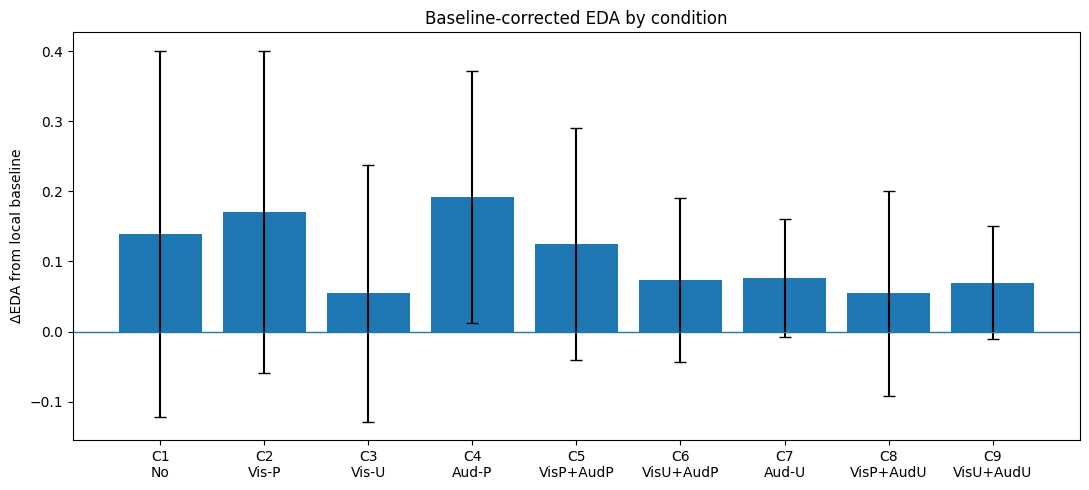

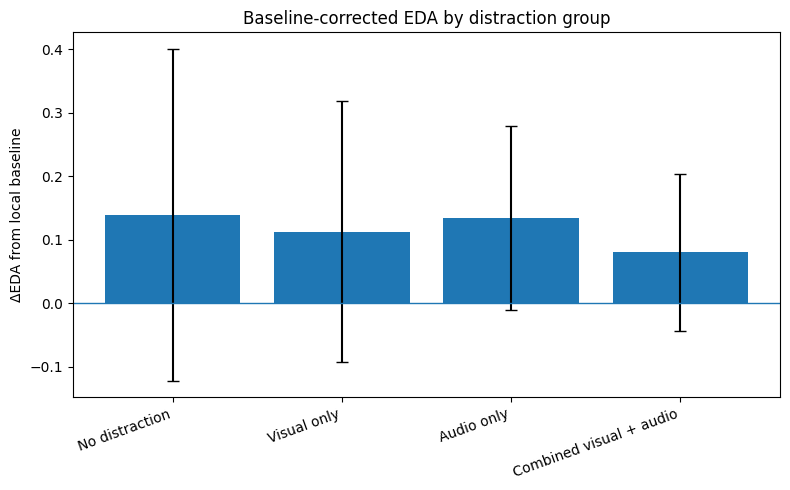

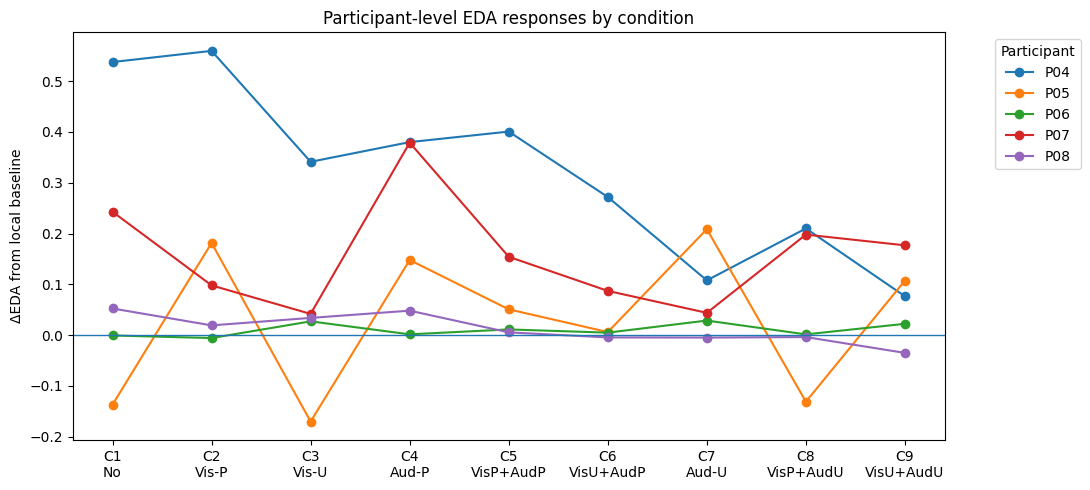

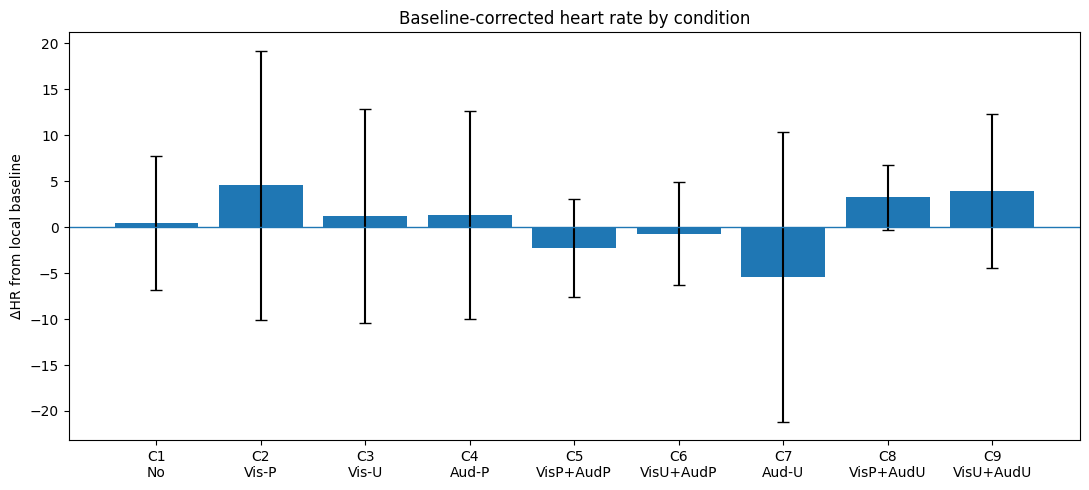

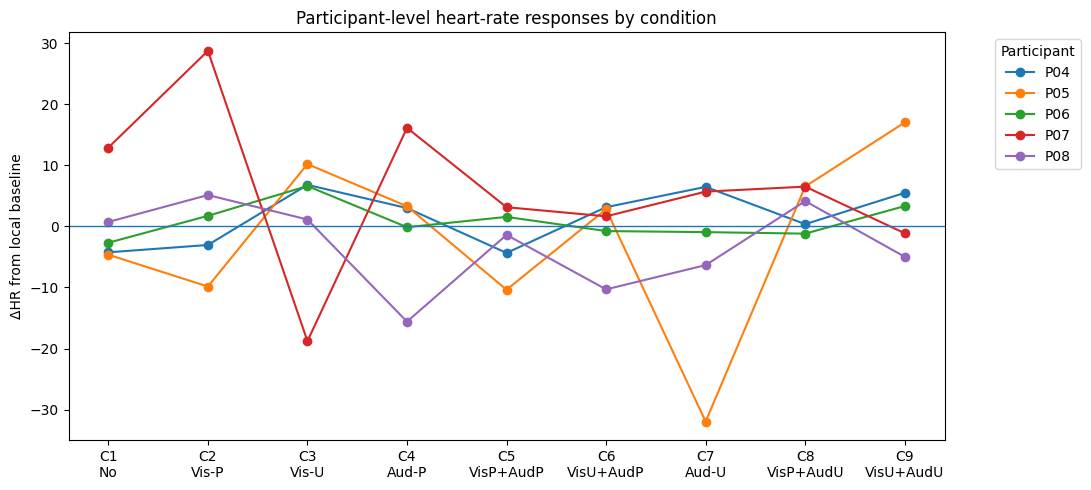

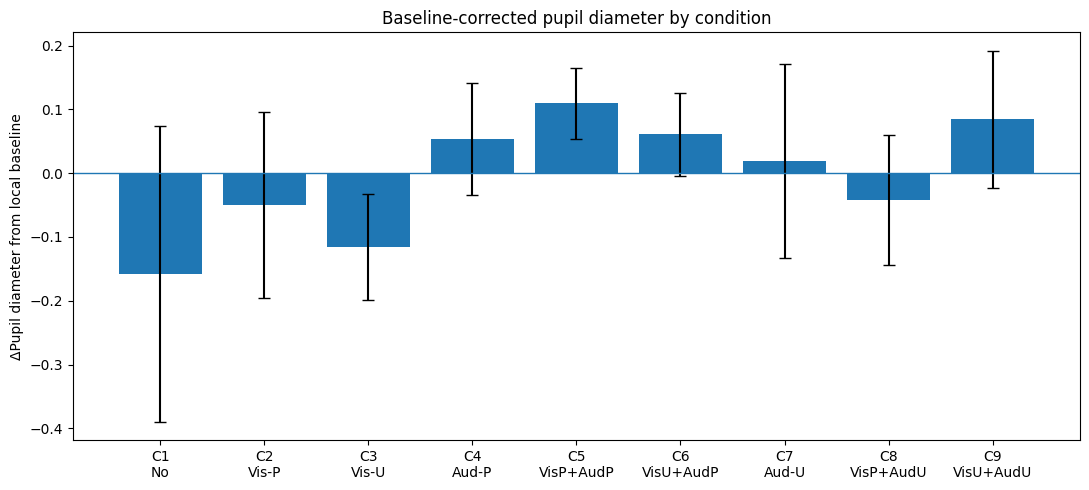

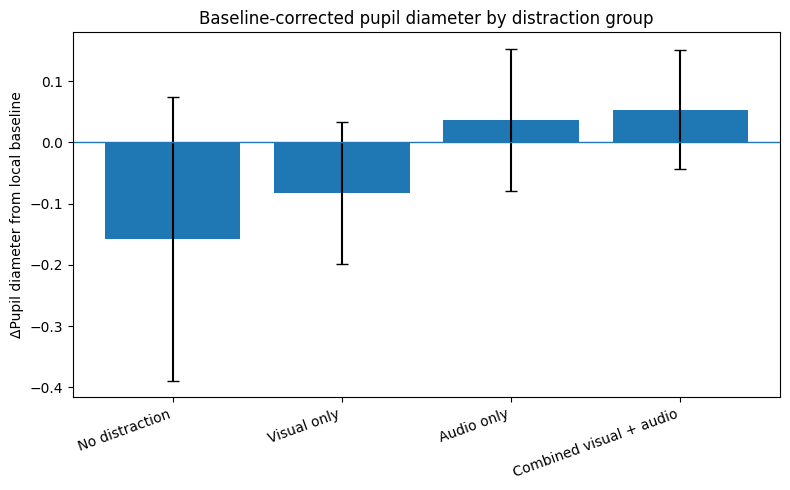

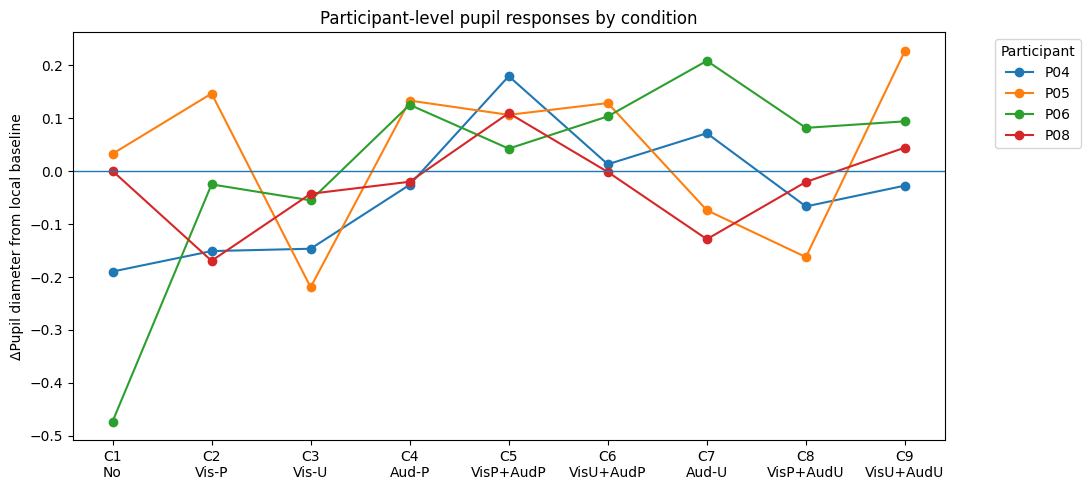

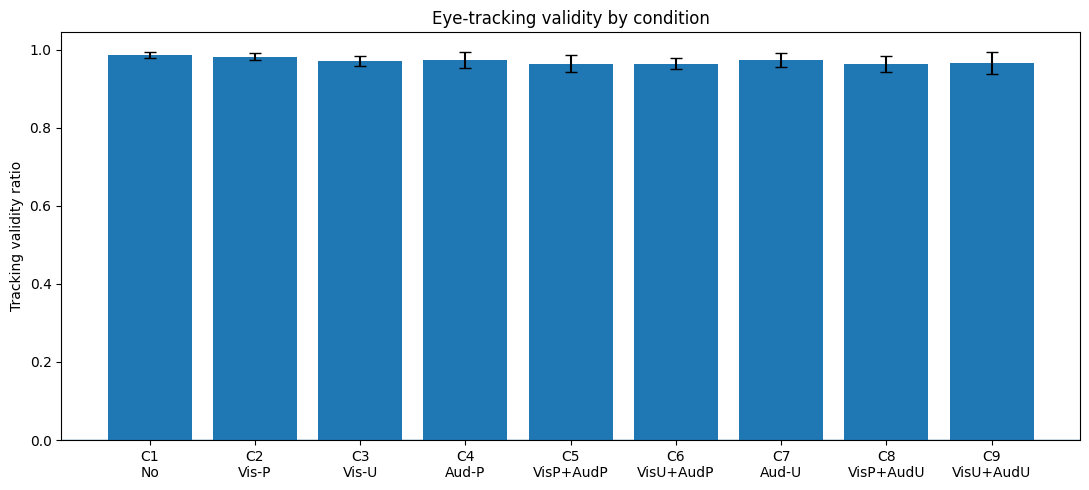

In [18]:
# EmotiBit figures
if len(emotibit_condition) > 0:
    save_condition_bar(
        emotibit_condition,
        "mean_delta_eda",
        "ΔEDA from local baseline",
        "Baseline-corrected EDA by condition",
        "delta_eda_by_condition_local.png",
        err_col="sd_delta_eda"
    )

    save_group_bar(
        emotibit_group,
        "mean_delta_eda",
        "ΔEDA from local baseline",
        "Baseline-corrected EDA by distraction group",
        "delta_eda_by_group_local.png",
        err_col="sd_delta_eda"
    )

    save_participant_lines(
        emotibit_main,
        "delta_eda_local",
        "ΔEDA from local baseline",
        "Participant-level EDA responses by condition",
        "participant_delta_eda_lines_local.png"
    )

    if "mean_delta_hr" in emotibit_condition.columns:
        save_condition_bar(
            emotibit_condition,
            "mean_delta_hr",
            "ΔHR from local baseline",
            "Baseline-corrected heart rate by condition",
            "delta_hr_by_condition_local.png",
            err_col="sd_delta_hr"
        )

        save_participant_lines(
            emotibit_main,
            "delta_hr_local",
            "ΔHR from local baseline",
            "Participant-level heart-rate responses by condition",
            "participant_delta_hr_lines_local.png"
        )

# Eye-tracking figures
if len(eye_condition) > 0:
    save_condition_bar(
        eye_condition,
        "mean_delta_pupil",
        "ΔPupil diameter from local baseline",
        "Baseline-corrected pupil diameter by condition",
        "delta_pupil_by_condition_local.png",
        err_col="sd_delta_pupil"
    )

    save_group_bar(
        eye_group,
        "mean_delta_pupil",
        "ΔPupil diameter from local baseline",
        "Baseline-corrected pupil diameter by distraction group",
        "delta_pupil_by_group_local.png",
        err_col="sd_delta_pupil"
    )

    save_participant_lines(
        eye_main,
        "delta_pupil_local",
        "ΔPupil diameter from local baseline",
        "Participant-level pupil responses by condition",
        "participant_delta_pupil_lines_local.png"
    )

    save_condition_bar(
        eye_condition,
        "mean_tracking_validity",
        "Tracking validity ratio",
        "Eye-tracking validity by condition",
        "tracking_validity_by_condition.png",
        err_col="sd_tracking_validity"
    )

## 19. Friedman tests

The Friedman test is a non-parametric repeated-measures test.  
It is used when the same participants are measured under several conditions and the sample size is small or normality cannot be assumed.

In this analysis, the Friedman test evaluates whether there is an overall difference between the nine experimental conditions for each measure:

- baseline-corrected EDA;
- baseline-corrected heart rate;
- baseline-corrected pupil diameter;
- adjusted NASA-TLX workload score.

Only participants with complete data across all conditions are included in each test.  
Kendall's W is also computed as an effect-size estimate, where larger values indicate stronger condition-related effects.

In [19]:
def friedman_by_condition(df, value_col, participant_col="participant", condition_col="condition"):
    if df is None or len(df) == 0:
        return {
            "measure": value_col,
            "n_participants": 0,
            "statistic": np.nan,
            "df": np.nan,
            "p_value": np.nan,
            "kendalls_w": np.nan,
            "status": "No data",
        }

    wide = df.pivot_table(
        index=participant_col,
        columns=condition_col,
        values=value_col,
        aggfunc="mean"
    )

    # We keep ordered condition columns that are present.
    ordered_cols = [c for c in CONDITION_ORDER if c in wide.columns]
    wide = wide[ordered_cols].dropna()

    n = wide.shape[0]
    k = wide.shape[1]

    if n < 2 or k < 3:
        return {
            "measure": value_col,
            "n_participants": n,
            "n_conditions": k,
            "statistic": np.nan,
            "df": k - 1 if k else np.nan,
            "p_value": np.nan,
            "kendalls_w": np.nan,
            "status": "Insufficient complete repeated-measures data",
        }

    stat, p = friedmanchisquare(*[wide[c].values for c in wide.columns])

    # Kendall's W effect size for Friedman:
    # W = chi-square / (n * (k - 1))
    w = stat / (n * (k - 1))

    return {
        "measure": value_col,
        "n_participants": n,
        "n_conditions": k,
        "statistic": stat,
        "df": k - 1,
        "p_value": p,
        "kendalls_w": w,
        "status": "OK",
    }


friedman_results = []

friedman_results.append(friedman_by_condition(emotibit_main, "delta_eda_local"))
friedman_results.append(friedman_by_condition(emotibit_main, "delta_hr_local"))
friedman_results.append(friedman_by_condition(eye_main, "delta_pupil_local"))
friedman_results.append(friedman_by_condition(questionnaire, "adjusted_score"))

friedman_results = pd.DataFrame(friedman_results)
friedman_results.to_csv(TABLE_DIR / "friedman_results.csv", index=False)

friedman_results

,measure,n_participants,n_conditions,statistic,df,p_value,kendalls_w,status
0,delta_eda_local,5,9,5.386667,8,0.715561,0.134667,OK
1,delta_hr_local,5,9,7.200000,8,0.515216,0.180000,OK
2,delta_pupil_local,4,9,14.000000,8,0.081765,0.437500,OK
3,adjusted_score,8,9,23.265902,8,0.003039,0.363530,OK


## 20. Planned Wilcoxon signed-rank comparisons

The Wilcoxon signed-rank test is a non-parametric paired test.  
It compares two related conditions measured from the same participants.

Here, Wilcoxon tests are used only for planned post-hoc comparisons between selected condition pairs.  
The comparisons focus on interpretable contrasts such as no-distraction versus combined-distraction conditions and predictable versus unpredictable versions of the same modality.

Bonferroni correction is applied within each measure to reduce the risk of false positives due to multiple comparisons.

In [20]:
def wilcoxon_comparison(df, value_col, condition_a, condition_b):
    wide = df.pivot_table(
        index="participant",
        columns="condition",
        values=value_col,
        aggfunc="mean"
    )

    if condition_a not in wide.columns or condition_b not in wide.columns:
        return {
            "measure": value_col,
            "condition_a": condition_a,
            "condition_b": condition_b,
            "n": 0,
            "statistic": np.nan,
            "p_value": np.nan,
            "status": "Missing condition",
        }

    pair = wide[[condition_a, condition_b]].dropna()
    n = len(pair)

    if n < 2:
        return {
            "measure": value_col,
            "condition_a": condition_a,
            "condition_b": condition_b,
            "n": n,
            "statistic": np.nan,
            "p_value": np.nan,
            "status": "Insufficient paired data",
        }

    try:
        stat, p = wilcoxon(pair[condition_a], pair[condition_b], zero_method="wilcox")
        status = "OK"
    except Exception as e:
        stat, p = np.nan, np.nan
        status = str(e)

    return {
        "measure": value_col,
        "condition_a": condition_a,
        "condition_b": condition_b,
        "n": n,
        "statistic": stat,
        "p_value": p,
        "status": status,
    }


# We keep post-hoc testing limited and interpretable.
# These are planned comparisons, not all possible pairwise comparisons.
planned_pairs = [
    ("C1_No_Distraction", "C5_VisualPredictable_AudioPredictable"),
    ("C1_No_Distraction", "C6_VisualUnpredictable_AudioPredictable"),
    ("C1_No_Distraction", "C9_VisualUnpredictable_AudioUnpredictable"),
    ("C2_Visual_Predictable", "C3_Visual_Unpredictable"),
    ("C4_Audio_Predictable", "C7_Audio_Unpredictable"),
]

wilcoxon_rows = []

for a, b in planned_pairs:
    wilcoxon_rows.append(wilcoxon_comparison(emotibit_main, "delta_eda_local", a, b))
    wilcoxon_rows.append(wilcoxon_comparison(emotibit_main, "delta_hr_local", a, b))
    wilcoxon_rows.append(wilcoxon_comparison(eye_main, "delta_pupil_local", a, b))

wilcoxon_results = pd.DataFrame(wilcoxon_rows)

# Bonferroni correction within each measure
wilcoxon_results["p_bonferroni"] = np.nan
for measure, idxs in wilcoxon_results.groupby("measure").groups.items():
    pvals = wilcoxon_results.loc[idxs, "p_value"]
    m = pvals.notna().sum()
    wilcoxon_results.loc[idxs, "p_bonferroni"] = np.minimum(pvals * m, 1.0)

wilcoxon_results.to_csv(TABLE_DIR / "planned_wilcoxon_results.csv", index=False)
wilcoxon_results

,measure,condition_a,condition_b,n,statistic,p_value,status,p_bonferroni
0,delta_eda_local,C1_No_Distraction,C5_VisualPredictable_AudioPredictable,5,6.0,0.8125,OK,1.000
1,delta_hr_local,C1_No_Distraction,C5_VisualPredictable_AudioPredictable,5,3.0,0.3125,OK,1.000
2,delta_pupil_local,C1_No_Distraction,C5_VisualPredictable_AudioPredictable,4,0.0,0.1250,OK,0.625
3,delta_eda_local,C1_No_Distraction,C6_VisualUnpredictable_AudioPredictable,5,4.0,0.4375,OK,1.000
4,delta_hr_local,C1_No_Distraction,C6_VisualUnpredictable_AudioPredictable,5,6.0,0.8125,OK,1.000
5,delta_pupil_local,C1_No_Distraction,C6_VisualUnpredictable_AudioPredictable,4,1.0,0.2500,OK,1.000
6,delta_eda_local,C1_No_Distraction,C9_VisualUnpredictable_AudioUnpredictable,5,5.0,0.6250,OK,1.000
7,delta_hr_local,C1_No_Distraction,C9_VisualUnpredictable_AudioUnpredictable,5,5.0,0.6250,OK,1.000
8,delta_pupil_local,C1_No_Distraction,C9_VisualUnpredictable_AudioUnpredictable,4,0.0,0.1250,OK,0.625
9,delta_eda_local,C2_Visual_Predictable,C3_Visual_Unpredictable,5,3.0,0.3125,OK,1.000


## 21. Ordering-effect inspection

Because all participants completed the experimental conditions in the same order, this section checks whether responses show a systematic trend across experimental rounds.  
This analysis is descriptive and is used to inspect possible learning, habituation, or fatigue effects.

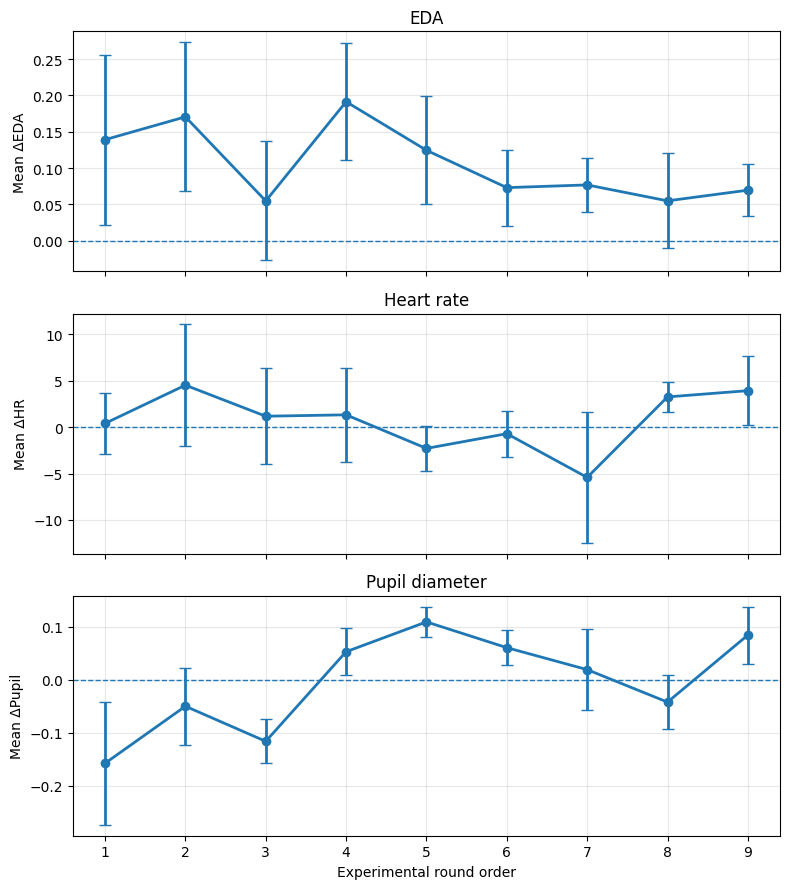

,round_index,mean_value,sd_value,n,sem_value,measure
0,1,0.139146,0.261173,5,0.116800,EDA
1,2,0.170571,0.229551,5,0.102658,EDA
2,3,0.054844,0.183040,5,0.081858,EDA
3,4,0.191382,0.179716,5,0.080371,EDA
4,5,0.124552,0.165567,5,0.074044,EDA
5,6,0.073152,0.117146,5,0.052389,EDA
6,7,0.076889,0.084287,5,0.037694,EDA
7,8,0.054977,0.146110,5,0.065342,EDA
8,9,0.069658,0.080855,5,0.036159,EDA
9,1,0.407528,7.291215,5,3.260731,Heart rate


In [21]:
ORDERING_OUTPUT = FIGURE_DIR / "ordering_effects_combined.png"

def summarize_by_round(df, value_col, label):
    summary = (
        df.dropna(subset=[value_col])
        .groupby("round_index", as_index=False)
        .agg(
            mean_value=(value_col, "mean"),
            sd_value=(value_col, "std"),
            n=("participant", "nunique")
        )
    )
    summary["sem_value"] = summary["sd_value"] / np.sqrt(summary["n"])
    summary["measure"] = label
    return summary

eda_order = summarize_by_round(
    emotibit_main,
    "delta_eda_local",
    "EDA"
)

hr_order = summarize_by_round(
    emotibit_main,
    "delta_hr_local",
    "Heart rate"
)

pupil_order = summarize_by_round(
    eye_main,
    "delta_pupil_local",
    "Pupil diameter"
)

ordering_summary = pd.concat(
    [eda_order, hr_order, pupil_order],
    ignore_index=True
)

ordering_summary.to_csv(
    TABLE_DIR / "ordering_effects_summary.csv",
    index=False
)

fig, axes = plt.subplots(3, 1, figsize=(8, 9), sharex=True)

plot_specs = [
    (axes[0], eda_order, "EDA", "Mean ΔEDA"),
    (axes[1], hr_order, "Heart rate", "Mean ΔHR"),
    (axes[2], pupil_order, "Pupil diameter", "Mean ΔPupil"),
]

for ax, data, title, ylabel in plot_specs:
    ax.errorbar(
        data["round_index"],
        data["mean_value"],
        yerr=data["sem_value"],
        marker="o",
        linewidth=2,
        capsize=4
    )
    ax.axhline(0, linestyle="--", linewidth=1)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Experimental round order")

plt.tight_layout()
plt.savefig(ORDERING_OUTPUT, dpi=300, bbox_inches="tight")
plt.show()

ordering_summary

## 22. Final output manifest

This section creates a manifest of all generated tables and figures.  
The manifest helps verify that all expected outputs were produced successfully.

In [22]:
output_files = []

for folder in [TABLE_DIR, FIGURE_DIR]:
    for f in sorted(folder.glob("*")):
        output_files.append({
            "folder": folder.name,
            "file": f.name,
            "path": str(f),
        })

output_manifest = pd.DataFrame(output_files)
output_manifest.to_csv(OUTPUT_DIR / "output_manifest.csv", index=False)
output_manifest

,folder,file,path
0,tables,behavior_condition_summary.csv,analysis_outputs/tables/behavior_condition_sum...
1,tables,behavior_quality_summary.csv,analysis_outputs/tables/behavior_quality_summa...
2,tables,behavior_round_summary_cleaned.csv,analysis_outputs/tables/behavior_round_summary...
3,tables,condition_metadata.csv,analysis_outputs/tables/condition_metadata.csv
4,tables,data_availability_table.csv,analysis_outputs/tables/data_availability_tabl...
5,tables,emotibit_condition_summary_local_baseline.csv,analysis_outputs/tables/emotibit_condition_sum...
6,tables,emotibit_group_summary_local_baseline.csv,analysis_outputs/tables/emotibit_group_summary...
7,tables,emotibit_inclusion_decisions.csv,analysis_outputs/tables/emotibit_inclusion_dec...
8,tables,emotibit_main_local_baseline.csv,analysis_outputs/tables/emotibit_main_local_ba...
9,tables,emotibit_quality_summary_local_baseline.csv,analysis_outputs/tables/emotibit_quality_summa...


## 23. Analysis summary

This notebook produced the final analysis outputs used in the BSP6 report.

Main outputs:

- participant-level data availability table;
- behavioral and questionnaire summaries;
- EmotiBit inclusion decisions;
- eye-tracking inclusion decisions;
- local-baseline-corrected EDA, HR, and pupil-diameter tables;
- Friedman test results;
- planned Wilcoxon signed-rank comparisons;
- report-ready figures;
- ordering-effect inspection figure.